# SmartCart Day 5b - Gradio Demo (SG edition)

The finale: a **self-checkout demo**. Upload a photo, the app detects products, recognizes each via the ONNX head, finds catalog matches, and totals the basket in **SGD** from the real FairPrice price table.

Adapted from Hongming's `Day5b_gradio_demo_updated.ipynb` (his `score_onnx_logits()` confidence scoring, `needs_review` flags, orange-box rendering, and review-count JSON are kept as-is). Changes: runs locally against `~/SmartCart_bundle`, serves the 25-class Singapore catalog, and the confidence threshold is the **calibrated** value Day 5a saved - not the 0.5 placeholder.

In [1]:
# 1) Runtime setup
%pip install -q timm ultralytics onnxruntime gradio

import os

# The cross-day bundle lives in a local folder (was a Google Drive mount on Colab).
BUNDLE_DIR = os.path.expanduser('~/SmartCart_bundle')



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip3.13 install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


### Embedded toolkit

This cell defines the helper functions used below. Run it once after setup.

In [2]:
from __future__ import annotations
import json
import os
import pathlib
import subprocess
import numpy as np
import pandas as pd
HERE = pathlib.Path.cwd()  # embedded in-notebook: no __file__, anchor on the working dir

class Bundle:
    """Small local folder that carries artifacts from one day to the next."""

    def __init__(self, root: str):
        self.root = pathlib.Path(root)
        self.root.mkdir(parents=True, exist_ok=True)
        self.manifest = {'version': 1, 'class_list': [], 'artifacts': {}}

    def put_table(self, name, df: pd.DataFrame):
        df.to_csv(self.root / name, index=False)
        self._note(name)

    def get_table(self, name) -> pd.DataFrame:
        return pd.read_csv(self.root / name)

    def put_array(self, name, arr: np.ndarray):
        np.save(self.root / name, arr)
        self._note(name)

    def get_array(self, name) -> np.ndarray:
        p = self.root / name
        return np.load(p if p.suffix == '.npy' else p.with_suffix('.npy'))

    def _note(self, name):
        self.manifest['artifacts'][name] = True

    def save(self):
        (self.root / 'manifest.json').write_text(json.dumps(self.manifest, indent=2))

    def load(self):
        p = self.root / 'manifest.json'
        if p.exists():
            self.manifest = json.loads(p.read_text())
        return self

def open_bundle(drive_dir=None) -> Bundle:
    """Open the cross-day local bundle. If it is new, start with an empty manifest."""
    return Bundle(drive_dir or os.path.expanduser('~/SmartCart_bundle')).load()

def save_bundle(b: Bundle):
    b.save()
    print(f'[bundle] saved -> {b.root}')

def load_backbone(name='vit_small_patch14_dinov2.lvd142m', device='cpu'):
    """Frozen DINOv2-small feature extractor."""
    import timm
    m = timm.create_model(name, pretrained=True, num_classes=0, dynamic_img_size=True).eval().to(device)
    for p in m.parameters():
        p.requires_grad_(False)
    return m

def extract_features(model, batches, device=None) -> np.ndarray:
    """Run image batches through a frozen backbone and return numpy features."""
    import torch
    if device is None:
        try:
            device = next(model.parameters()).device
        except (AttributeError, StopIteration):
            device = 'cpu'
    outs = []
    with torch.no_grad():
        for xb in batches:
            y = model(xb.to(device))
            outs.append(y.detach().cpu().numpy().astype('float32'))
    return np.concatenate(outs, 0)

class EmbeddingIndex:
    """Cosine nearest-neighbor index over catalog/gallery embeddings."""

    def __init__(self):
        self._nn = None
        self.meta = []

    def build(self, feats: np.ndarray, meta: list[dict]):
        from sklearn.neighbors import NearestNeighbors
        f = feats / (np.linalg.norm(feats, axis=1, keepdims=True) + 1e-08)
        self._nn = NearestNeighbors(n_neighbors=min(10, len(f)), metric='cosine').fit(f)
        self.meta = meta
        self._feats = f
        return self

    def query(self, q: np.ndarray, k=5):
        qn = q / (np.linalg.norm(q, axis=1, keepdims=True) + 1e-08)
        dist, idx = self._nn.kneighbors(qn, n_neighbors=min(k, len(self.meta)))
        return [[{**self.meta[j], 'score': float(1 - d)} for d, j in zip(drow, irow)] for drow, irow in zip(dist, idx)]

    def save(self, b: Bundle, prefix='gallery'):
        b.put_array(f'{prefix}_index.npy', self._feats)
        b.put_table(f'{prefix}_meta.csv', pd.DataFrame(self.meta))

    @classmethod
    def load(cls, b: Bundle, prefix='gallery'):
        feats = b.get_array(f'{prefix}_index.npy')
        meta = b.get_table(f'{prefix}_meta.csv').to_dict('records')
        return cls().build(feats, meta)

def basket_total(items, prices, default=0.0):
    return float(sum((prices.get(it['fine'], default) for it in items)))

def score_onnx_logits(logits, classes):
    """Softmax-confidence scoring for raw ONNX Runtime output (Hongming's addition) -
    this notebook serves via sess.run(), not a PyTorch head, so the scoring math is
    redone against that output shape."""
    logits = logits[0] if logits.ndim == 2 else logits
    probs = np.exp(logits - logits.max())
    probs = probs / probs.sum()
    pred_id = int(np.argmax(logits))
    return {'pred_id': pred_id, 'pred_name': classes[pred_id], 'confidence': float(probs[pred_id])}

# Fallback only - the load cell below overrides this with the calibrated value
# that Day 5a saved into the bundle (confidence_threshold.json).
CONFIDENCE_THRESHOLD = 0.5

print('SmartCart toolkit ready')


SmartCart toolkit ready


In [3]:
# 2) Load the cross-day bundle
b = open_bundle(BUNDLE_DIR)
print('bundle:', b.root)
print('artifacts:', list(b.manifest.get('artifacts', {})))


bundle: /home/jonyling/SmartCart_bundle
artifacts: ['sample_scene.jpg', 'detector.pt', 'crops_manifest.csv', 'gallery_index.npy', 'gallery_meta.csv', 'catalog_prices.csv', 'labels.csv', 'head.pt', 'per_class_metrics.csv', 'error_report.md', 'head_v2.pt', 'lift_table.csv', 'lift_table_vs_real_photo.csv', 'decisive_lift_table.csv', 'confidence_threshold.json', 'head.onnx', 'crops_train.csv', 'calibration_crops.csv']


## Load model + catalog prices

**What:** Open an ONNX session for the head, load the gallery, `catalog_prices.csv`, the detector + backbone, and the **calibrated confidence threshold** from Day 5a.

**Why:** These are the exact runtime pieces the app needs - no training, just serving.

In [4]:
from pathlib import Path
import onnxruntime as ort
import pandas as pd
import torch
sess = ort.InferenceSession(str(Path(b.root)/'head.onnx'))
idx = EmbeddingIndex.load(b)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('using device:', device)
model = load_backbone(device=device)
classes = b.manifest.get('class_list') or sorted({m['fine'] for m in idx.meta})
price_catalog = b.get_table('catalog_prices.csv')
prices = dict(zip(price_catalog.fine, price_catalog.unit_price))
currency = price_catalog.currency.iloc[0] if 'currency' in price_catalog else 'USD'
from ultralytics import YOLO
det = YOLO(str(Path(b.root)/'detector.pt'))
# Serve with the SAME threshold Day 5a calibrated on real detector crops.
thr_file = Path(b.root)/'confidence_threshold.json'
if thr_file.exists():
    cal = json.loads(thr_file.read_text())
    CONFIDENCE_THRESHOLD = float(cal['threshold'])
    print(f"calibrated CONFIDENCE_THRESHOLD = {CONFIDENCE_THRESHOLD} "
          f"(from Day 5a sweep on {cal['n_crops']} detector crops, target acc {cal['target_acc']:.0%})")
else:
    print(f'confidence_threshold.json not found - using fallback {CONFIDENCE_THRESHOLD} (run Day 5a first)')
print('serving', len(classes), 'classes with', len(prices), 'catalog prices in', currency)


using device: cuda


/home/jonyling/miniconda3/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


calibrated CONFIDENCE_THRESHOLD = 0.6 (from Day 5a sweep on 52 detector crops, target acc 98%)
serving 25 classes with 25 catalog prices in SGD


## Inference function

**What:** Define `recognize(image)`: detect -> crop -> embed -> ONNX softmax-confidence -> label, then total the basket. Low-confidence items render with an orange box, a `?` in the label, and a `needs_review` flag; the JSON includes `needs_review_count` and a note when the total contains best-guess prices (Hongming's design, unchanged).

**Why:** This single function is the app's brain; Gradio just wraps it with a UI.

In [5]:
import torch, torchvision.transforms.v2 as T
from PIL import Image, ImageDraw
import numpy as np
TF = T.Compose([T.ToImage(), T.Resize((224,224)), T.ToDtype(torch.float32, scale=True),
                T.Normalize([0.485,0.456,0.406],[0.229,0.224,0.225])])
def feats_of_imgs(imgs, model):
    """Embed PIL crops without saving them to disk."""
    xs = torch.stack([TF(im.convert('RGB')) for im in imgs])
    return extract_features(model, [xs])
def recognize(image):
    img = image.convert('RGB'); arr = np.array(img); draw = ImageDraw.Draw(img)
    result = det(arr, imgsz=640, conf=0.05, verbose=False)[0]
    boxes = result.boxes.xyxy.cpu().numpy()
    if len(boxes) == 0:
        boxes = np.array([[0, 0, img.width, img.height]], dtype='float32')
    items, rows = [], []
    # One row per detected product. Confidence is checked here, not just predicted -
    # this is the live demo end users actually click.
    for x1,y1,x2,y2 in boxes:
        crop = Image.fromarray(arr[int(y1):int(y2), int(x1):int(x2)])
        f = feats_of_imgs([crop], model)
        logits = sess.run(None, {'feat': f.astype('float32')})[0]
        s = score_onnx_logits(logits, classes)
        label = s['pred_name']
        needs_review = s['confidence'] < CONFIDENCE_THRESHOLD
        similar = [h['fine'] for h in idx.query(f, k=3)[0]]
        items.append({'fine': label})
        rows.append({'item': label, 'confidence': round(s['confidence'], 3), 'needs_review': bool(needs_review),
                     'price': float(prices.get(label, 0.0)), 'currency': currency, 'similar': similar})
        box_label = f"{label} ({s['confidence']:.0%})" + (' ?' if needs_review else '')
        box_color = 'orange' if needs_review else 'red'
        draw.rectangle([x1,y1,x2,y2], outline=box_color, width=3); draw.text((x1,y1), box_label, fill=box_color)
    total = basket_total(items, prices, default=1.0)  # unknown SKUs priced at a flat 1.00
    n_review = sum(r['needs_review'] for r in rows)
    return img, {'items': rows, 'total': round(total, 2), 'currency': currency,
                 'needs_review_count': n_review, 'note': 'includes best-guess price for flagged items' if n_review else None}
print('recognize() ready')


recognize() ready


## Smoke test on a real photo (no UI needed)

**What:** Run `recognize()` on one of the genuinely real photos from `sg_data/sg_dataset/natural/` and print the receipt JSON.

**Why:** Proves the whole serving path (YOLO -> DINOv2 -> ONNX -> confidence gate -> SGD receipt) works end-to-end before anyone launches a browser - and it runs headlessly in CI/nbconvert.

input: Maggi-Curry-Noodles_home_001.jpg
{
  "items": [
    {
      "item": "Maggi-Curry-Noodles",
      "confidence": 0.806,
      "needs_review": false,
      "price": 2.25,
      "currency": "SGD",
      "similar": [
        "Koka-Noodles",
        "Maggi-Curry-Noodles",
        "Prima-Taste-Laksa"
      ]
    },
    {
      "item": "Khong-Guan-Biscuits",
      "confidence": 0.575,
      "needs_review": true,
      "price": 2.7,
      "currency": "SGD",
      "similar": [
        "Koka-Noodles",
        "SongHe-Rice",
        "Gardenia-White-Bread"
      ]
    },
    {
      "item": "Koka-Noodles",
      "confidence": 0.813,
      "needs_review": false,
      "price": 2.4,
      "currency": "SGD",
      "similar": [
        "Koka-Noodles",
        "Gardenia-White-Bread",
        "Maggi-Curry-Noodles"
      ]
    },
    {
      "item": "Maggi-Curry-Noodles",
      "confidence": 0.961,
      "needs_review": false,
      "price": 2.25,
      "currency": "SGD",
      "similar": [
       

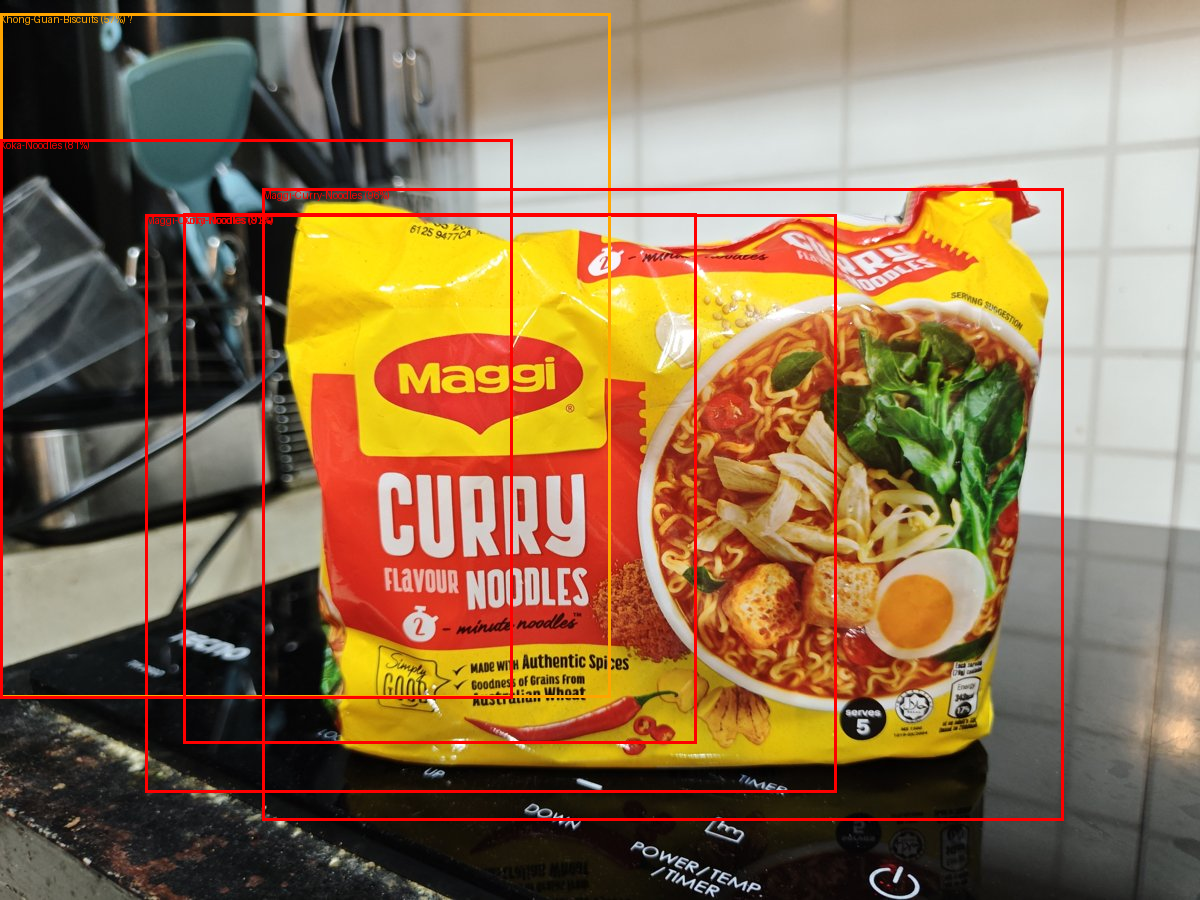

In [6]:
sg_natural = HERE.parent / 'sg_data' / 'sg_dataset' / 'natural'
test_photo = sg_natural / 'Noodles' / 'Maggi-Curry-Noodles' / 'Maggi-Curry-Noodles_home_001.jpg'
if test_photo.exists():
    out_img, receipt = recognize(Image.open(test_photo))
    print('input:', test_photo.name)
    print(json.dumps(receipt, indent=2, default=str))
    display(out_img)
else:
    print('real photo not found at', test_photo, '- adjust the path for your machine')


## Launch the app

**What:** Launch the Gradio interface (guarded so headless runs don't block on a server).

**Why:** A local URL (or `share=True` link) lets teammates try the self-checkout from their phones.

**Watch for:** Set `SC_LAUNCH_GRADIO=1` before running to actually launch; on WSL open the printed localhost URL from the Windows browser. Add `share=True` inside `launch()` for a public link.

In [7]:
if os.environ.get('SC_LAUNCH_GRADIO','0')=='1':
    import gradio as gr
    demo = gr.Interface(fn=recognize, inputs=gr.Image(type='pil'), outputs=['image','json'],
                        title='SmartCart self-checkout (Singapore edition)')
    demo.launch()
else:
    print('Set SC_LAUNCH_GRADIO=1 to launch the app (kept off for headless runs).')


Set SC_LAUNCH_GRADIO=1 to launch the app (kept off for headless runs).


## Week recap

You built the full deployable-vision loop on a home-grown Singapore dataset: **acquire (D1) -> localize (D2) -> recognize (D3) -> augment + prove the lift (D4) -> assemble, calibrate + ship (D5)**. The receipt is in SGD, the prices are real FairPrice medians, the confidence threshold is calibrated on real detector crops, and the recognition head is the copy-paste-augmented one that scored 80% on real photos vs 51% baseline.